In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

df1 = pd.read_csv("./raw/us-financial-indicators/main.csv", parse_dates=["date"])
df2 = pd.read_csv("./raw/how-financial-crisis-are-born/global_crisis_data.csv")
df2_us = df2[df2["iso3"] == "USA"].copy()
df2_us["year"] = df2_us["year"].astype(int)

df1["year"] = df1["date"].dt.year
df1_anual = df1.groupby("year")[["Interest_Rate","Inflation","GDP",
                                  "Unemployment","Ind_Prod","sp500"]].mean().reset_index()

cols_df2 = ["year","crisis_any","crisis_next_12m","banking_crisis_next_12m",
            "currency_crisis_next_12m","fed_funds_rate","real_interest_rate_10y"]
cols_df2 = [c for c in cols_df2 if c in df2_us.columns]
df_merged = pd.merge(df1_anual, df2_us[cols_df2], on="year", how="inner")

features = ["Interest_Rate", "Inflation", "GDP", "Unemployment", "Ind_Prod", "sp500"]
df_pca = df_merged[features + ["crisis_any", "crisis_next_12m", "year"]].dropna()

X = df_pca[features].values
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         9
         1.0       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



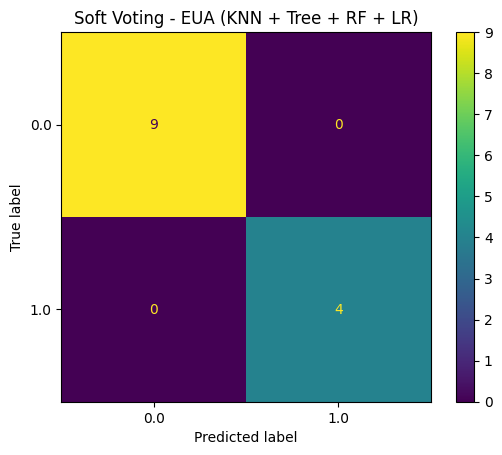

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = df_merged[features]
y = df_merged["crisis_next_12m"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

# KNN 
knn = Pipeline([
    ("scaler", scaler),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

# Árvore (não precisa scaler)
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Regressão Logística 
logreg = Pipeline([
    ("scaler", scaler),
    ("model", LogisticRegression(max_iter=1000))
])

voting = VotingClassifier(
    estimators=[
        ("knn", knn),
        ("tree", tree),
        ("rf", rf),
        ("logreg", logreg)
    ],
    voting="soft"
)

voting.fit(X_train, y_train)

y_pred = voting.predict(X_test)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(
    voting,
    X_test,
    y_test
)

plt.title("Soft Voting - EUA (KNN + Tree + RF + LR)")
plt.show()